In [69]:
##OKLMA GoesR

import xarray as xr
import numpy as np
from datetime import date, time, datetime, timedelta

file = "/Users/Indhuja/Downloads/GOESR_CRS_L1B_20170517_v0.nc"
fdate = '2017-05-17'
def add24hr(hr):
    """Correction of time in CRS for going over the next day in UTC"""
    b = np.where(hr < hr[0])
    hr[b] = hr[b] + 24
    return hr

with xr.open_dataset(file, decode_cf=False) as ds:
    CRSlat = ds['lat'].values
    CRSlon = ds['lon'].values
    hr = add24hr(ds['time'].values)
    print(ds['time'].values, hr)
    Time = (hr * 3600).astype('timedelta64[s]') + np.datetime64(fdate)
    CRStime = (Time - np.datetime64('1970-01-01')).astype('timedelta64[s]').astype(np.int64)

print(CRStime)
sec0 = CRStime[0] + (600 - CRStime[0] % 600)  # <---starts on 10-min mark (may 17 2017 2:30)
secf = CRStime[-1] - CRStime[-1] % 600  # <---ends on 10-min mark (may 17 2017 7:30)
Trng = int(secf - sec0)  # <---range for data
tstart = datetime(1970, 1, 1) + timedelta(seconds=int(sec0))
print(sec0, secf, Trng, tstart)

Tsize = 60  # <-- in [sec]              #<--tile for every Tsize sec
nTile = int((secf - sec0) / Tsize) + 1
print(nTile, Tsize)

t1970 = datetime(1970, 1, 1)
t1 = datetime(int(fdate[0:4]), int(fdate[5:7]), int(fdate[8:10]))
dSecs = (t1 - t1970).total_seconds()
print(t1970, t1, dSecs)

for tile in range(nTile):
    epoch = sec0 + tile * Tsize
    end = min(epoch + Tsize, secf)
    print(epoch, end,"\n")
    print(epoch - dSecs, end - dSecs)

[2.4758337 2.4758978 2.4758914 ... 7.589774  7.589837  7.5899005] [2.4758337 2.4758978 2.4758914 ... 7.589774  7.589837  7.5899005]
[1494988113 1494988113 1494988113 ... 1495006523 1495006523 1495006523]
1494988200 1495006200 18000 2017-05-17 02:30:00
301 60
1970-01-01 00:00:00 2017-05-17 00:00:00 1494979200.0
1494988200 1494988260 

9000.0 9060.0
1494988260 1494988320 

9060.0 9120.0
1494988320 1494988380 

9120.0 9180.0
1494988380 1494988440 

9180.0 9240.0
1494988440 1494988500 

9240.0 9300.0
1494988500 1494988560 

9300.0 9360.0
1494988560 1494988620 

9360.0 9420.0
1494988620 1494988680 

9420.0 9480.0
1494988680 1494988740 

9480.0 9540.0
1494988740 1494988800 

9540.0 9600.0
1494988800 1494988860 

9600.0 9660.0
1494988860 1494988920 

9660.0 9720.0
1494988920 1494988980 

9720.0 9780.0
1494988980 1494989040 

9780.0 9840.0
1494989040 1494989100 

9840.0 9900.0
1494989100 1494989160 

9900.0 9960.0
1494989160 1494989220 

9960.0 10020.0
1494989220 1494989280 

10020.0 10080.0
1

In [5]:
import re
import pandas as pd
def clean_line(line):
    line = re.sub(r'\s+',' ', line)
    line = line.strip()
    line = line.split(" ")
    return line

def get_col_index_map():
    # represents the column number for each key, inside the input csv type file.
    return {
        "Year": 0,
        "Day": 1,
        "Hour": 2,
        "Min": 3,
        "drops": 4,
        "conc": 5,
        "water content": 6,
        "rain rate": 7,
        "reflectivity": 8,
        "mass-weight d.d": 9,
        "max d.d": 10,
    }

file = open("/Users/Indhuja/Desktop/APU/apu09/olympex_apu09_20151203_rainparameter_min.txt", 'r')
print(file)
lines = file.readlines()
print(len(lines))
modified_lines = []
for line in lines:
    if(type(line) == str):
        modified_line = clean_line(line)
    else:
        modified_line = clean_line(line.decode())
    modified_lines.append(modified_line)

data = pd.DataFrame(modified_lines)
data.columns = ['Year', 'Day', 'Hour', 'Min', 'drops', 'conc', 'l.w.c', 'rain rate', 'reflectivity', 'mass-weight d.d', 'max d.d']
print(data)

# data.Day.unique()

<_io.TextIOWrapper name='/Users/Indhuja/Desktop/APU/apu09/olympex_apu09_20151203_rainparameter_min.txt' mode='r' encoding='UTF-8'>
1374
      Year  Day Hour Min drops     conc  l.w.c rain rate reflectivity  \
0     2015  337    0   4   31.   68.261  0.002     0.011       -5.474   
1     2015  337    0   6   72.  114.113  0.007     0.056        3.221   
2     2015  337    0   7   91.  172.126  0.007     0.043        0.670   
3     2015  337    0   8  124.  260.830  0.010     0.073        6.025   
4     2015  337    0   9  154.  215.209  0.029     0.323       14.351   
...    ...  ...  ...  ..   ...      ...    ...       ...          ...   
1369  2015  337   23  55  490.  552.371  0.164     2.561       29.102   
1370  2015  337   23  56  432.  455.236  0.168     2.805       30.660   
1371  2015  337   23  57  502.  542.513  0.193     3.188       30.965   
1372  2015  337   23  58  525.  598.606  0.166     2.563       29.748   
1373  2015  337   23  59  588.  670.512  0.189     2.915     

In [4]:
import datetime

for d in data.Day.unique():
    x = datetime.datetime.strptime(f'15{d}', '%y%j').date()
    y = x.strftime('%Y%m%d')
    print(d, y)


327 20151123
328 20151124
334 20151130
335 20151201
336 20151202
337 20151203
338 20151204
339 20151205
340 20151206
341 20151207
342 20151208
343 20151209
349 20151215
350 20151216


In [8]:
start_time = "142855" #add correction of time for going over the next day in UTC
end_time = "164955"

start_time = int(start_time[:-2])
end_time = int(end_time[:-2])
start_date = int(20151203)
end_date = int(20151203)
print(start_time, end_time)
# data['Hour'] = data['Hour'].str.zfill(2) #add leading zeroes to single digits
# data['Min'] = data['Min'].str.zfill(2)

y = "20151203"
data['Time'] = data['Hour'] + data['Min']
data['Time'] = data['Time'].astype(int)
# print(data['Time'].tolist())
data['Timestamp'] = pd.to_datetime(y + ' ' + data['Hour'].astype(str) + ':' + data['Min'].astype(str), format='%Y%m%d %H:%M')
data['Seconds'] = pd.to_timedelta(data['Timestamp'].dt.time.astype(str)).dt.total_seconds()

filtered_data = data[(data['Time'] > start_time) & (data['Time'] < end_time)]
# print(filtered_data, len(filtered_data))
data['Seconds']

1428 1649


0         240.0
1         360.0
2         420.0
3         480.0
4         540.0
         ...   
1369    86100.0
1370    86160.0
1371    86220.0
1372    86280.0
1373    86340.0
Name: Seconds, Length: 1374, dtype: float64

In [9]:
import json
import numpy as np

def color_encode(data, min_value, max_value, opa=255, RGBA=False):
    # Define the number of colors in the gradient
    num_colors = 100  # Number of colors in the gradient

    # Generate the gradient from blue to red
    colors = np.linspace([0, 0, 1], [1, 0, 0], num_colors, dtype=np.float32)

    # Add opacity if RGBA is True
    if RGBA:
        colors = np.column_stack((colors, np.full(num_colors, opa, dtype=np.uint8)))

    # Convert min_value and max_value to numerical values
    min_value = float(min_value)
    max_value = float(max_value)

    # Normalize the parameter values
    values = data['rain rate'].astype(float).values
    normalized_values = (values - min_value) / (max_value - min_value)

    # Clip normalized values to ensure they are within [0, 1]
    normalized_values = np.clip(normalized_values, 0, 1)

    # Map the parameter values to colors in the gradient
    color_indices = (normalized_values * (num_colors - 1)).astype(int)
    encoded_colors = colors[color_indices]

    return encoded_colors

# Example usage
encoded_colors = color_encode(data, data['rain rate'].min(), data['rain rate'].max(), RGBA=False)
# print(encoded_colors)

main_dict = {}
for index, row in data.iterrows():
    row_dict = {index: {"id": int(data['Seconds'].iloc[index].item()), "r": encoded_colors[index][0].item(), "b": encoded_colors[index][2].item()}}
    main_dict.update(row_dict)
main_dict

with open("output_file_20151203.json", "w") as f:
    json.dump(main_dict, f, indent=4)


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import numpy as np

starttime = data['Hour'].iloc[0]
endtime = data['Hour'].iloc[len(data)-1]
# time_range = pd.date_range('2016-12-02T11:00:00.000Z', '2017-06-06T07:00:00.000Z', freq='H')
# timestamps = [str(x) + 'Z' for x in time_range]
# time_range = pd.date_range(starttime, endtime, freq="2h").strftime('%H')
# print(time_range)
time_24 = [t for t in range(int(starttime), int(endtime), 2)]
print(time_24)

print(data)

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]
      Year  Day Hour Min drops     conc  l.w.c rain rate reflectivity  \
0     2015  337    0   4   31.   68.261  0.002     0.011       -5.474   
1     2015  337    0   6   72.  114.113  0.007     0.056        3.221   
2     2015  337    0   7   91.  172.126  0.007     0.043        0.670   
3     2015  337    0   8  124.  260.830  0.010     0.073        6.025   
4     2015  337    0   9  154.  215.209  0.029     0.323       14.351   
...    ...  ...  ...  ..   ...      ...    ...       ...          ...   
1369  2015  337   23  55  490.  552.371  0.164     2.561       29.102   
1370  2015  337   23  56  432.  455.236  0.168     2.805       30.660   
1371  2015  337   23  57  502.  542.513  0.193     3.188       30.965   
1372  2015  337   23  58  525.  598.606  0.166     2.563       29.748   
1373  2015  337   23  59  588.  670.512  0.189     2.915       29.545   

     mass-weight d.d max d.d  Time           Timestamp  Seconds  
0            

In [11]:
df = pd.concat([data['rain rate'], data['Hour']], axis=1)
print(df)
minValue = df['rain rate'].min()
maxValue = df['rain rate'].max()
print(minValue, maxValue)


     rain rate Hour
0        0.011    0
1        0.056    0
2        0.043    0
3        0.073    0
4        0.323    0
...        ...  ...
1369     2.561   23
1370     2.805   23
1371     3.188   23
1372     2.563   23
1373     2.915   23

[1374 rows x 2 columns]
0.011 9.992


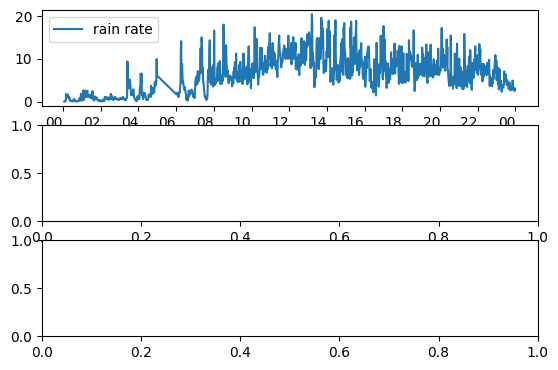

<Figure size 1500x600 with 0 Axes>

In [13]:
import matplotlib.pyplot as plt

import matplotlib.dates as md

fig, axis = plt.subplots(3,1) #add another param here
# plt.subplot(3, 1, 1)
plt.figure(figsize=(15, 6))
data['rain rate'] = pd.to_numeric(data['rain rate'])
ax = data.plot(ax=axis[0], y='rain rate', x='Timestamp')
ax.xaxis.set_major_locator(md.HourLocator(interval=2))
ax.xaxis.set_major_formatter(md.DateFormatter('%H'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation = 0 )
# ax2 = fig.add_subplot(2,1,2)
# ax2.plot(data['Timestamp'], data['conc'])
plt.show()


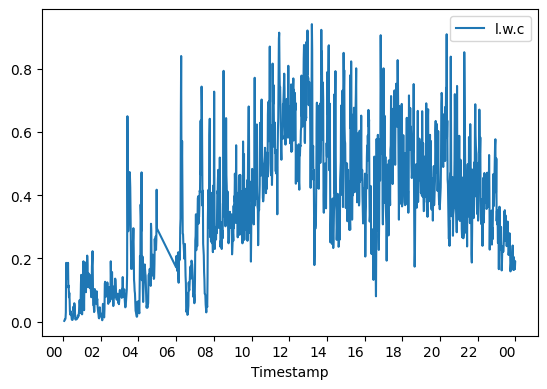

In [14]:

import matplotlib.pyplot as plt
import pandas as pd
data['l.w.c'] = pd.to_numeric(data['l.w.c'])
ax = data.plot(y='l.w.c', x='Timestamp')
ax.xaxis.set_major_locator(md.HourLocator(interval=2))
ax.xaxis.set_major_formatter(md.DateFormatter('%H'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation = 0 )
plt.show()


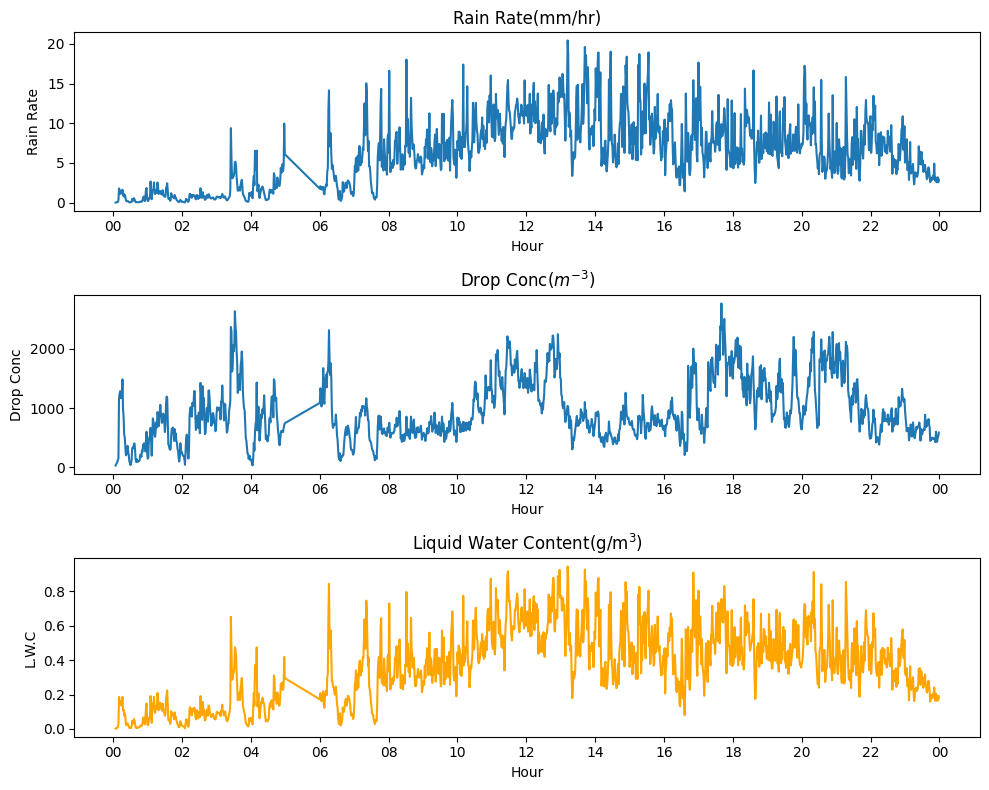

In [15]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as md

# Assuming 'data' is your DataFrame containing the necessary data

# Convert columns to numeric if they are not already
data['rain rate'] = pd.to_numeric(data['rain rate'])
data['drops'] = pd.to_numeric(data['drops'])
data['l.w.c'] = pd.to_numeric(data['l.w.c'])

# Create a figure and two subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 8))

# Plot 'rain rate' data
axs[0].plot(data['Timestamp'], data['rain rate'])
axs[0].xaxis.set_major_locator(md.HourLocator(interval=2))
axs[0].xaxis.set_major_formatter(md.DateFormatter('%H'))
axs[0].set_title('Rain Rate(mm/hr)')
axs[0].set_xlabel('Hour')
axs[0].set_ylabel('Rain Rate')

# Plot 'drop conc' data
axs[1].plot(data['Timestamp'], data['drops'])
axs[1].xaxis.set_major_locator(md.HourLocator(interval=2))
axs[1].xaxis.set_major_formatter(md.DateFormatter('%H'))
axs[1].set_title('Drop Conc($m^{-3}$)')
axs[1].set_xlabel('Hour')
axs[1].set_ylabel('Drop Conc')

# Plot 'l.w.c' data
axs[2].plot(data['Timestamp'], data['l.w.c'], color='orange')  # Change color if needed
axs[2].xaxis.set_major_locator(md.HourLocator(interval=2))
axs[2].xaxis.set_major_formatter(md.DateFormatter('%H'))
axs[2].set_title('Liquid Water Content(g/m$^3$)')
axs[2].set_xlabel('Hour')
axs[2].set_ylabel('L.W.C')

# Rotate x-axis tick labels for both subplots
for ax in axs:
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the combined figure with multiple subplots
plt.show()
